# SmartHire — Exploratory Data Analysis (EDA)
### Project: Resume-to-Job Matching & Career Guidance Engine
**Scope**: Exploration of the 525 job postings corpus across 15 categories, analyzing skill frequencies, salary/location dynamics, and cross-domain market patterns.
**Constraints**: Classical Machine Learning foundation (no LLMs, no generative AI, no live scraping).


In [1]:
import re
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10


## 1. Data Ingestion & Schema Inspection
Loading the raw job postings corpus (`data/raw/job_postings.csv`).


In [2]:
DATA_PATH = Path("../data/raw/job_postings.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values:\n{df.isnull().sum()}")
df.head(3)


Dataset Shape: 525 rows, 9 columns
Missing Values:
Job_ID                 0
Title                  0
Category               0
Company                0
Location               0
Skills                 0
Experience_Required    0
Salary_LPA             0
Description            0
dtype: int64


,Job_ID,Title,Category,Company,Location,Skills,Experience_Required,Salary_LPA,Description
0,JOB00291,Marketing Analyst,Digital Marketing,Brennan-Johnson,Chennai,Marketing Strategy; Communication; Excel; PPC;...,5-8 years,16-24,Exciting opportunity for a Marketing Analyst a...
1,JOB00109,Senior Java Developer,Java Developer,Hancock and Sons,Delhi NCR,JUnit; Microservices; Hibernate; Java; Multith...,2-5 years,5-12,We are looking for a Senior Java Developer to ...
2,JOB00049,Frontend Developer,Web Development,Hickman Ltd,Bengaluru,MongoDB; React; CSS; Node.js; REST API,5-8 years,19-22,Hickman Ltd is hiring a Frontend Developer for...


## 2. Feature Parsing & Transformation
We extract structured numerical columns from `Experience_Required` and `Salary_LPA`, and tokenize semicolon-delimited `Skills`.


In [3]:
def parse_skills(s):
    if not isinstance(s, str) or not s.strip(): return []
    return [x.strip() for x in re.split(r"[;,]", s) if x.strip()]

def parse_experience(exp):
    nums = [float(n) for n in re.findall(r"\d+", str(exp))]
    if len(nums) >= 2: return nums[0], nums[1], (nums[0] + nums[1]) / 2.0
    elif len(nums) == 1: return nums[0], nums[0] + 2.0, nums[0] + 1.0
    return 0.0, 1.0, 0.5

def parse_salary(sal):
    nums = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", str(sal))]
    if len(nums) >= 2: return nums[0], nums[1], (nums[0] + nums[1]) / 2.0
    elif len(nums) == 1: return nums[0], nums[0], nums[0]
    return 0.0, 0.0, 0.0

df['parsed_skills'] = df['Skills'].apply(parse_skills)
df['skills_count'] = df['parsed_skills'].apply(len)

exp_tuples = df['Experience_Required'].apply(parse_experience)
df['min_exp'] = [t[0] for t in exp_tuples]
df['max_exp'] = [t[1] for t in exp_tuples]
df['avg_exp'] = [t[2] for t in exp_tuples]

sal_tuples = df['Salary_LPA'].apply(parse_salary)
df['min_salary'] = [t[0] for t in sal_tuples]
df['max_salary'] = [t[1] for t in sal_tuples]
df['avg_salary'] = [t[2] for t in sal_tuples]

df[['Job_ID', 'Title', 'Category', 'avg_exp', 'avg_salary', 'skills_count']].head()


,Job_ID,Title,Category,avg_exp,avg_salary,skills_count
0,JOB00291,Marketing Analyst,Digital Marketing,6.5,20.0,5
1,JOB00109,Senior Java Developer,Java Developer,3.5,8.5,7
2,JOB00049,Frontend Developer,Web Development,6.5,20.5,5
3,JOB00017,Data Scientist,Data Science,6.5,9.0,7
4,JOB00312,SEO Specialist,Digital Marketing,7.5,12.5,5


## 3. Job Category Distribution
Checking class balance across target domains. Balanced classes ensure the supervised category classifier (Model A) is not biased toward over-represented sectors.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\3910602924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="mako")


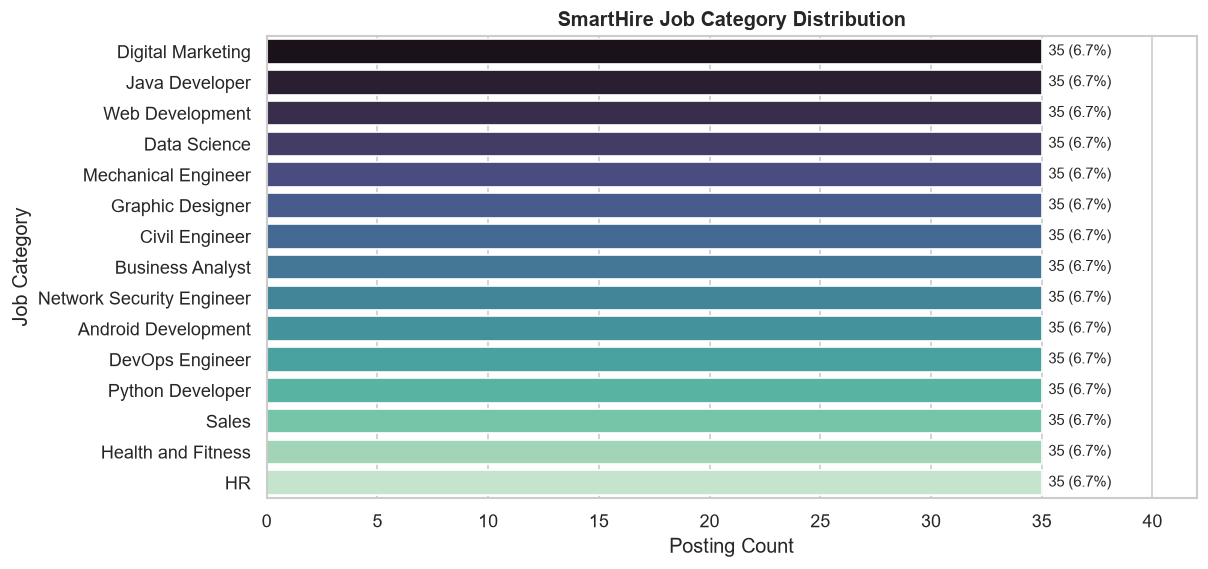

In [4]:
plt.figure(figsize=(10, 5))
cat_counts = df['Category'].value_counts()
ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="mako")
plt.title("SmartHire Job Category Distribution", weight="bold")
plt.xlabel("Posting Count")
plt.ylabel("Job Category")
for i, v in enumerate(cat_counts.values):
    ax.text(v + 0.3, i, f"{v} ({v/len(df)*100:.1f}%)", va="center", fontsize=9)
plt.xlim(0, 42)
plt.show()


## 4. Skill Frequency Analysis by Category
We evaluate the dominant skills required within distinct engineering and functional career paths.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\599864239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\599864239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\599864239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\599864239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\599864239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\599864239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")


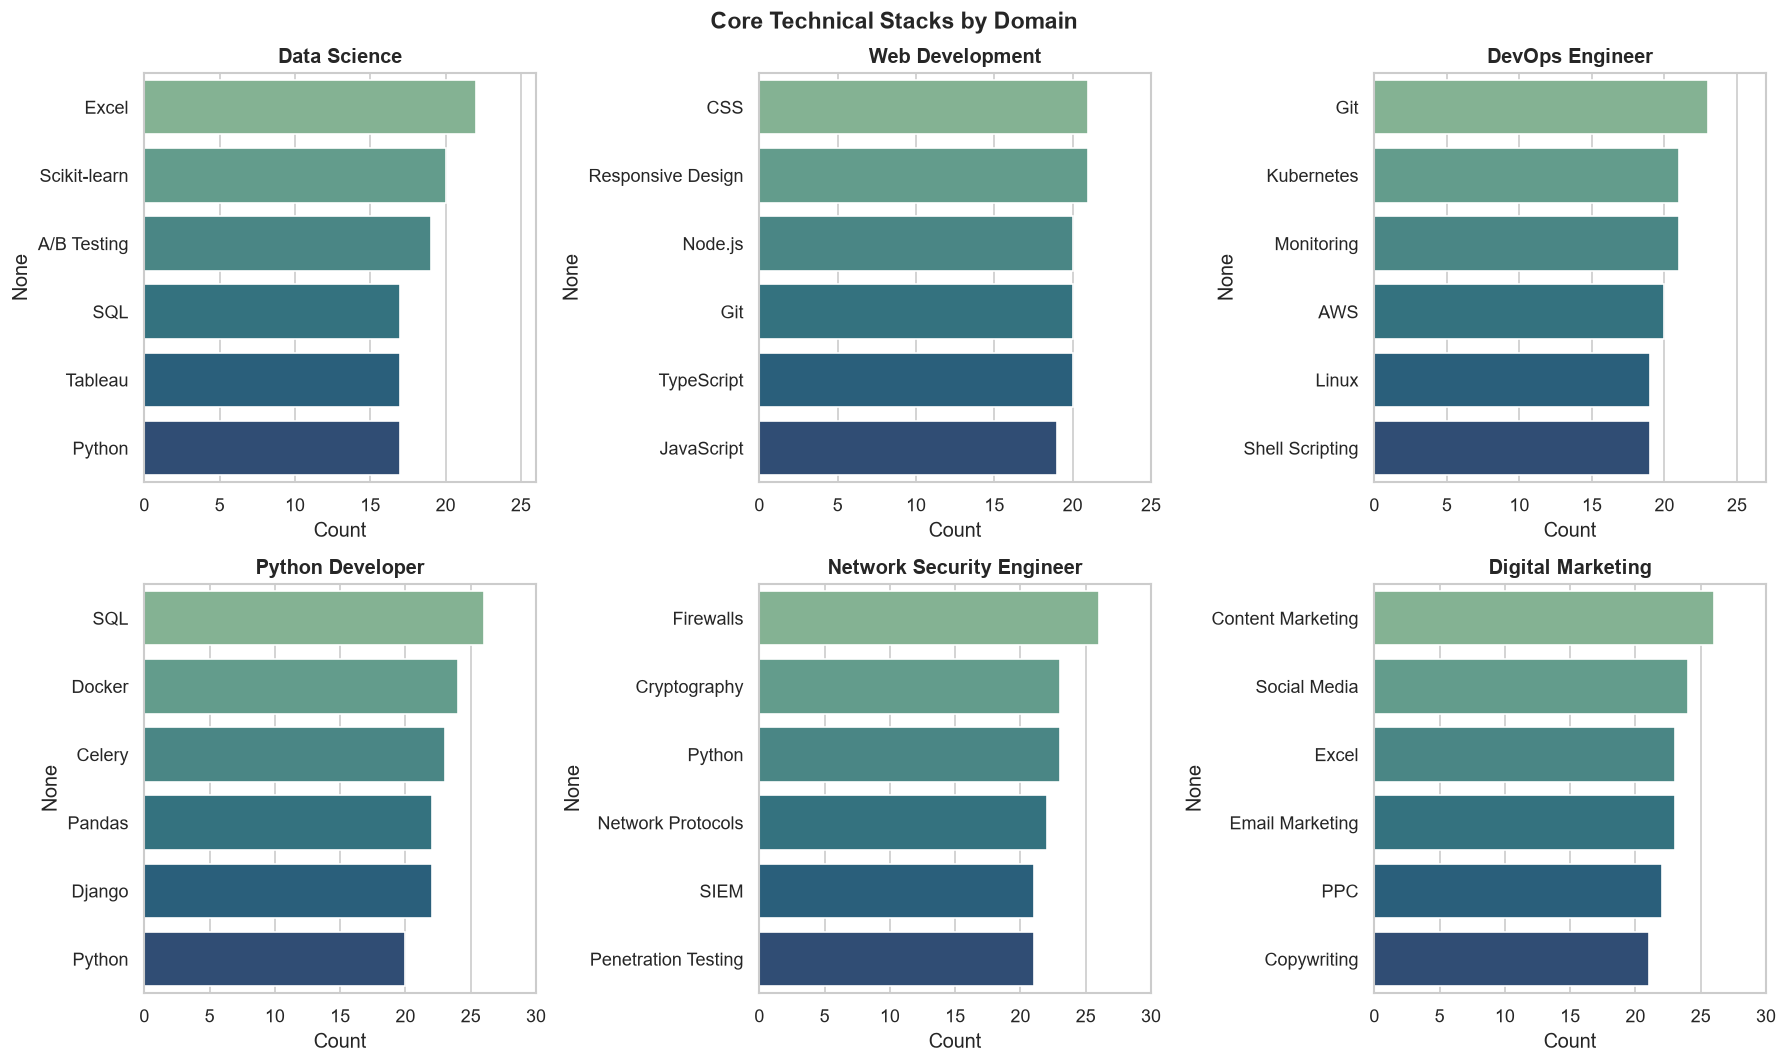

In [5]:
target_cats = ['Data Science', 'Web Development', 'DevOps Engineer', 'Python Developer', 'Network Security Engineer', 'Digital Marketing']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, cat in enumerate(target_cats):
    sub = df[df['Category'] == cat]
    all_s = [s for slist in sub['parsed_skills'] for s in slist]
    top_s = pd.Series(all_s).value_counts().head(6)
    
    sns.barplot(ax=axes[idx], x=top_s.values, y=top_s.index, palette="crest")
    axes[idx].set_title(f"{cat}", weight="bold")
    axes[idx].set_xlabel("Count")
    axes[idx].set_xlim(0, max(top_s.values) + 4)

plt.suptitle("Core Technical Stacks by Domain", weight="bold", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Compensation & Geographic Dynamics
Evaluating salary ranges across categories and tech hubs in India.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\1638045587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax1, x=sal_cat.values, y=sal_cat.index, palette="viridis")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\1638045587.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax2, x=sal_loc['mean'].values, y=sal_loc.index, palette="flare")


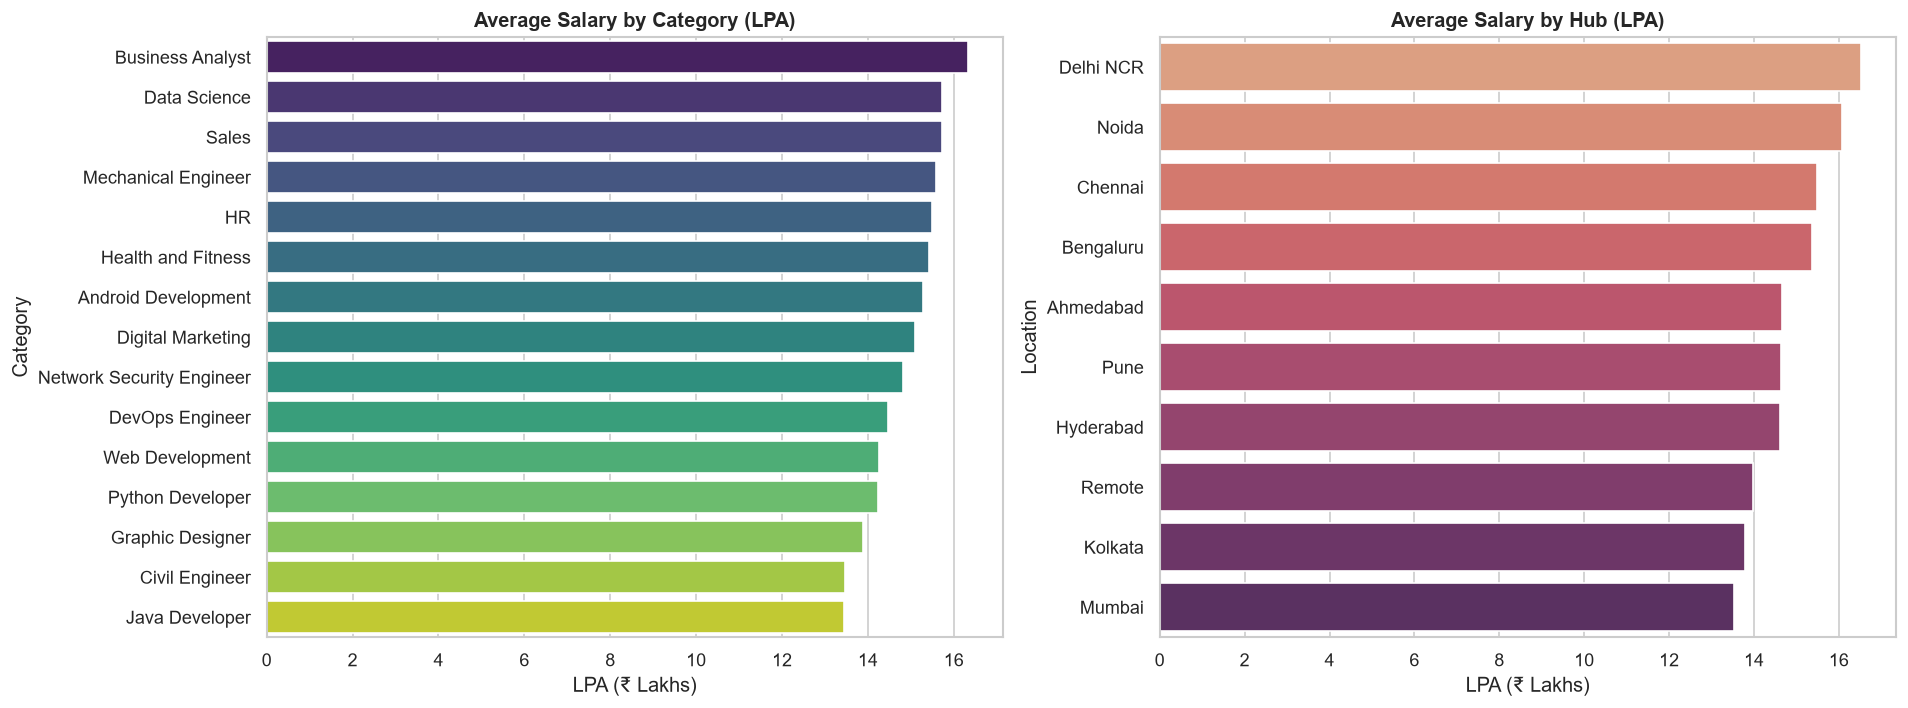

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mean Salary by Category
sal_cat = df.groupby('Category')['avg_salary'].mean().sort_values(ascending=False)
sns.barplot(ax=ax1, x=sal_cat.values, y=sal_cat.index, palette="viridis")
ax1.set_title("Average Salary by Category (LPA)", weight="bold")
ax1.set_xlabel("LPA (₹ Lakhs)")

# Mean Salary by Location
sal_loc = df.groupby('Location')['avg_salary'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
sns.barplot(ax=ax2, x=sal_loc['mean'].values, y=sal_loc.index, palette="flare")
ax2.set_title("Average Salary by Hub (LPA)", weight="bold")
ax2.set_xlabel("LPA (₹ Lakhs)")

plt.tight_layout()
plt.show()


## 6. Genuinely Interesting Insights

### Insight 1: Universal "Bridge Skills"
Which skills transcend boundaries and appear in the greatest number of categories?
Candidates with these bridge skills possess natural flexibility to pivot across multiple industries.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2060\1723033209.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bridge, x='Category_Count', y='Skill', palette="crest")


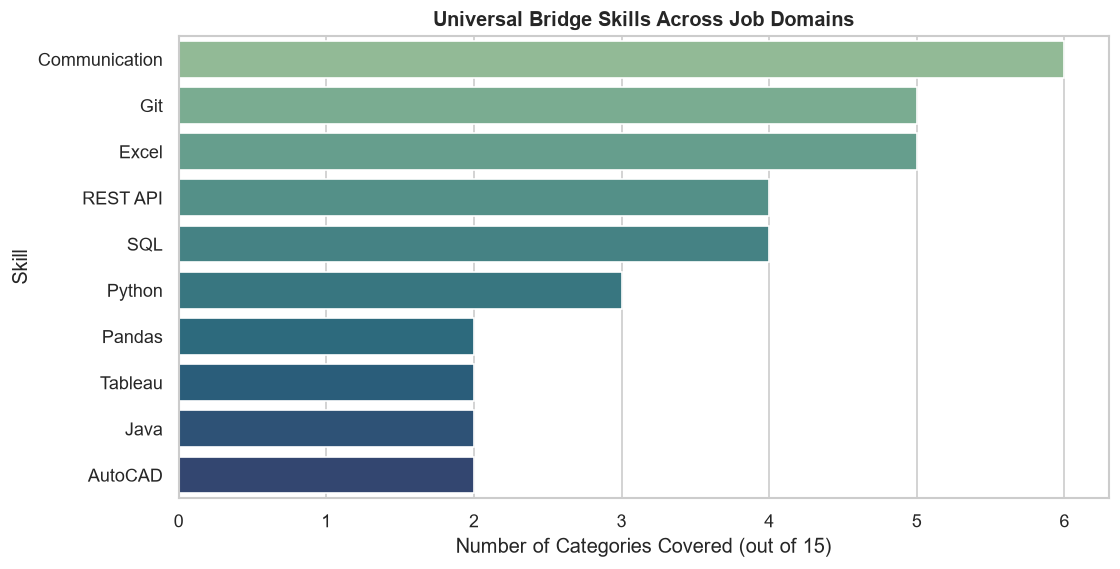

,Skill,Category_Count,Categories
1,Communication,6,"Business Analyst, Digital Marketing, Graphic D..."
10,Git,5,"Android Development, DevOps Engineer, Java Dev..."
2,Excel,5,"Business Analyst, Data Science, Digital Market..."
16,REST API,4,"Android Development, Java Developer, Python De..."
17,SQL,4,"Business Analyst, Data Science, Java Developer..."
22,Python,3,"Data Science, Network Security Engineer, Pytho..."
21,Pandas,2,"Data Science, Python Developer"
20,Tableau,2,"Business Analyst, Data Science"
8,Java,2,"Android Development, Java Developer"
28,AutoCAD,2,"Civil Engineer, Mechanical Engineer"


In [7]:
skill_cat_map = {}
for _, row in df.iterrows():
    for s in row['parsed_skills']:
        skill_cat_map.setdefault(s, set()).add(row['Category'])

bridge_df = pd.DataFrame([
    {'Skill': s, 'Category_Count': len(cats), 'Categories': ', '.join(sorted(cats))}
    for s, cats in skill_cat_map.items()
]).sort_values(by='Category_Count', ascending=False)

plt.figure(figsize=(10, 5))
top_bridge = bridge_df.head(10)
sns.barplot(data=top_bridge, x='Category_Count', y='Skill', palette="crest")
plt.title("Universal Bridge Skills Across Job Domains", weight="bold")
plt.xlabel("Number of Categories Covered (out of 15)")
plt.show()

top_bridge[['Skill', 'Category_Count', 'Categories']]


### Insight 2: High-Paying Niches & Entry-Level Premiums
Where do candidates gain the highest early-career return on investment?
We segment job postings into experience tiers:
- **Junior (0-3 yrs)**
- **Mid-Level (4-7 yrs)**
- **Senior (8-11 yrs)**


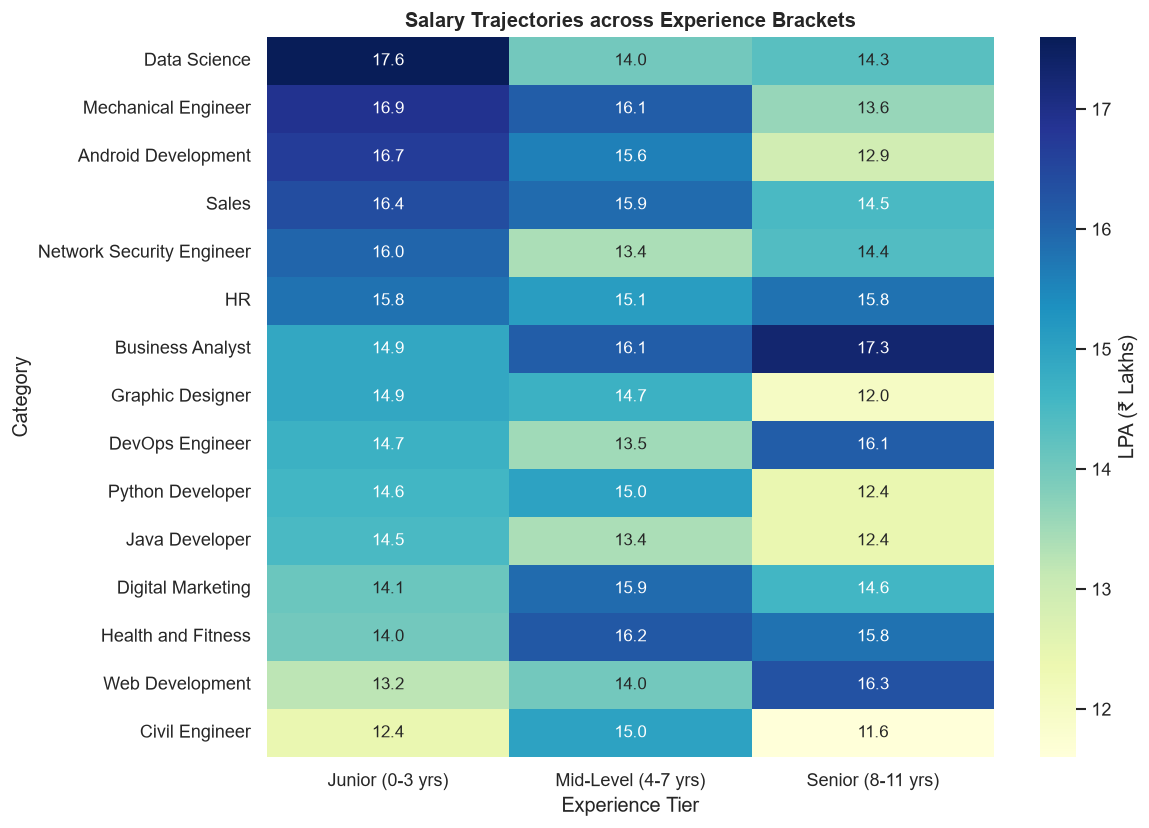

exp_bracket,Junior (0-3 yrs),Mid-Level (4-7 yrs),Senior (8-11 yrs)
Category,,,
Data Science,17.6,14.0,14.3
Mechanical Engineer,16.9,16.1,13.6
Android Development,16.7,15.6,12.9
Sales,16.4,15.9,14.5
Network Security Engineer,16.0,13.4,14.4
HR,15.8,15.1,15.8
Business Analyst,14.9,16.1,17.3
Graphic Designer,14.9,14.7,12.0
DevOps Engineer,14.7,13.5,16.1


In [8]:
df['exp_bracket'] = pd.cut(
    df['avg_exp'],
    bins=[-0.1, 3.5, 7.5, 15.0],
    labels=["Junior (0-3 yrs)", "Mid-Level (4-7 yrs)", "Senior (8-11 yrs)"]
)

pivot_salary = df.pivot_table(
    index="Category",
    columns="exp_bracket",
    values="avg_salary",
    aggfunc="mean"
).round(1).sort_values(by="Junior (0-3 yrs)", ascending=False)

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_salary, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'LPA (₹ Lakhs)'})
plt.title("Salary Trajectories across Experience Brackets", weight="bold")
plt.xlabel("Experience Tier")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

pivot_salary


## 7. Conclusions & Preparation for Phase 2
### Summary of EDA Findings:
1. **Perfect Class Balance**: The dataset features exactly 35 records per category across 15 distinct job categories (525 total rows), establishing a reliable benchmark for multi-class classification.
2. **Domain-Specific Skill Signatures**: Key roles have distinct skill vocabularies (e.g. Kotlin/Android SDK for Mobile; Spring Boot/Hibernate for Java; AWS/Terraform/Docker for DevOps; AutoCAD/Revit for Civil).
3. **Bridge Competencies**: Foundational tools like `Communication`, `Excel`, `SQL`, `Python`, and `Git` bridge multiple sectors.
4. **Compensation Drivers**: Domains like `Network Security Engineer`, `DevOps Engineer`, and `Data Science` exhibit the highest entry-level packages (>15 LPA average at 0-3 years), making them high-value target recommendations.

We are ready to proceed with **Phase 2: Supervised Category Classifier (Model A)**.
